SVM


In [62]:
!unzip dataset.zip

Archive:  dataset.zip
replace __MACOSX/._Bengin cases? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Bengin cases/Bengin case (85).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace __MACOSX/Bengin cases/._Bengin case (85).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Bengin cases/Bengin case (109).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace __MACOSX/Bengin cases/._Bengin case (109).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Bengin cases/Bengin case (93).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace __MACOSX/Bengin cases/._Bengin case (93).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Bengin cases/Bengin case (50).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace __MACOSX/Bengin cases/._Bengin case (50).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Bengin cases/Bengin case (11).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace __MACOSX/Bengin cases/._Bengin case (11).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Bengin cas


## Load and Inspect Data

### Subtask:
Load the unzipped image dataset and inspect its structure. This involves identifying image paths, corresponding labels, and understanding basic image properties.


**Reasoning**:
I will load the unzipped image dataset, identify image paths and labels, and inspect basic image properties as instructed. This involves importing necessary libraries, traversing directories, and printing sample image details.



In [63]:
import os
from PIL import Image
from collections import Counter

# Define the main directory where the unzipped dataset is located
dataset_dir = '/content/'

# Initialize empty lists to store image paths and their corresponding labels
image_paths = []
labels = []

# List of expected subdirectories based on the unzip output
class_names = ['Bengin cases', 'Malignant cases', 'Normal cases']

print(f"Scanning directory: {dataset_dir}\n")

# Iterate through the subdirectories
for class_name in class_names:
    class_dir = os.path.join(dataset_dir, class_name)
    if os.path.exists(class_dir) and os.path.isdir(class_dir):
        print(f"Processing class directory: {class_dir}")
        # Iterate through the image files within each subdirectory
        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                img_path = os.path.join(class_dir, filename)
                image_paths.append(img_path)
                labels.append(class_name)
    else:
        print(f"Warning: Class directory not found or not a directory: {class_dir}")


# Print the total number of images found
print(f"\nTotal number of images found: {len(image_paths)}")

# Print the number of images per class
label_counts = Counter(labels)
print("Number of images per class:")
for label, count in label_counts.items():
    print(f"- {label}: {count}")

# Load a sample image and print its dimensions and mode
if image_paths:
    sample_image_path = image_paths[0]
    try:
        with Image.open(sample_image_path) as img:
            print(f"\nSample image path: {sample_image_path}")
            print(f"Sample image dimensions: {img.size}")
            print(f"Sample image mode: {img.mode}")
    except Exception as e:
        print(f"Error loading sample image {sample_image_path}: {e}")
else:
    print("No images found to display sample properties.")

Scanning directory: /content/

Processing class directory: /content/Bengin cases
Processing class directory: /content/Malignant cases
Processing class directory: /content/Normal cases

Total number of images found: 1097
Number of images per class:
- Bengin cases: 120
- Malignant cases: 561
- Normal cases: 416

Sample image path: /content/Bengin cases/Bengin case (75).jpg
Sample image dimensions: (512, 512)
Sample image mode: RGB


## Preprocess Data

### Subtask:
Prepare the image data for SVM training. This involves resizing and flattening images into numerical features, encoding categorical labels, splitting the data into training and testing sets, and scaling the features.


**Reasoning**:
I will import the necessary libraries, define an image preprocessing function, apply it to all images, encode the labels, split the data, and scale the features as per the instructions to prepare the data for SVM training.



In [64]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from PIL import Image
import os

# Define the preprocessing function
def preprocess_image(image_path, target_size=(64, 64)):
    with Image.open(image_path) as img:
        # Resize the image
        img = img.resize(target_size)
        # Convert to grayscale
        img = img.convert('L')
        # Convert to numpy array and flatten
        img_array = np.array(img).flatten()
    return img_array

# Apply preprocessing to all images
X = []
for img_path in image_paths:
    X.append(preprocess_image(img_path))
X = np.array(X)

print(f"Shape of feature matrix X after flattening: {X.shape}")

# Encode categorical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

print(f"Shape of target vector y: {y.shape}")
print(f"Encoded labels: {label_encoder.classes_}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Scale the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

print("Image data preprocessing complete.")

Shape of feature matrix X after flattening: (1097, 4096)
Shape of target vector y: (1097,)
Encoded labels: ['Bengin cases' 'Malignant cases' 'Normal cases']
Shape of X_train: (767, 4096)
Shape of X_test: (330, 4096)
Shape of y_train: (767,)
Shape of y_test: (330,)
Shape of X_train_scaled: (767, 4096)
Shape of X_test_scaled: (330, 4096)
Image data preprocessing complete.


## Train SVM with Hyperparameter Tuning

### Subtask:
Train a Support Vector Machine (SVM) model. Use techniques like GridSearchCV or RandomizedSearchCV to perform hyperparameter tuning to achieve high accuracy.


**Reasoning**:
I will provide the code to import necessary libraries, define a parameter grid, instantiate an SVC model, create and fit a GridSearchCV object, and then print the best parameters and best score as per the instructions.



In [65]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 2. Define a parameter grid for GridSearchCV
param_grid = {
    'C': [0.1],
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'kernel': ['rbf']
}

# 3. Instantiate an SVC model
svm = SVC(random_state=42)

# 4. Create a GridSearchCV object
# Using a smaller cv (e.g., 2 or 3) for quicker execution during initial exploration
grid_search = GridSearchCV(svm, param_grid, cv=5, verbose=2, n_jobs=-1)

print("Starting GridSearchCV...")
# 5. Fit the GridSearchCV object to your scaled training data
grid_search.fit(X_train_scaled, y_train)
print("GridSearchCV complete.")

# 6. Print the best parameters found by GridSearchCV
print(f"Best parameters found: {grid_search.best_params_}")

# 7. Print the best cross-validation score achieved
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Starting GridSearchCV...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
GridSearchCV complete.
Best parameters found: {'C': 0.1, 'gamma': 0.0001, 'kernel': 'rbf'}
Best cross-validation score: 0.7431


## Evaluate Model Performance

### Subtask:
Evaluate the performance of the best SVM model on the test set using appropriate metrics such as accuracy, precision, recall, and F1-score.


**Reasoning**:
I will import necessary metrics from `sklearn.metrics`, retrieve the best model from `grid_search`, make predictions on the test set, and then calculate and print the accuracy and a classification report.



In [66]:
from sklearn.metrics import accuracy_score, classification_report

# Retrieve the best estimator from GridSearchCV
best_svm_model = grid_search.best_estimator_

# Make predictions on the scaled test set
y_pred = best_svm_model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")

# Generate and print the classification report
# Using target_names to make the report more readable with original class names
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Model Accuracy on Test Set: 0.7697

Classification Report:
                 precision    recall  f1-score   support

   Bengin cases       0.00      0.00      0.00        36
Malignant cases       0.77      0.94      0.85       169
   Normal cases       0.77      0.76      0.76       125

       accuracy                           0.77       330
      macro avg       0.51      0.57      0.54       330
   weighted avg       0.69      0.77      0.72       330



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Visualize Results

### Subtask:
Generate a visualization, such as a confusion matrix, to better understand the model's performance and classification results. Include labels and a legend for clarity.


**Reasoning**:
To visualize the model's performance, I will generate a confusion matrix as a heatmap. This involves importing necessary libraries, calculating the confusion matrix from the predicted and actual labels, and then plotting it with appropriate labels and a title.



In [67]:
y_train_pred = best_svm_model.predict(X_train_scaled)
print("Predictions on training data (y_train_pred) made successfully.")

Predictions on training data (y_train_pred) made successfully.


In [68]:
from sklearn.metrics import accuracy_score

# Calculate training accuracy
training_accuracy = accuracy_score(y_train, y_train_pred)

# Print the training accuracy
print(f"Model Training Accuracy: {training_accuracy:.4f}")

Model Training Accuracy: 0.7784


In [69]:
print(f"Training Accuracy: {training_accuracy:.4f}")
print(f"Testing Accuracy: {accuracy:.4f}")

print("Accuracy values gathered successfully.")

Training Accuracy: 0.7784
Testing Accuracy: 0.7697
Accuracy values gathered successfully.


In [70]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the training data
cm_train = confusion_matrix(y_train, y_train_pred)

print("Training Confusion Matrix calculated successfully.")

Training Confusion Matrix calculated successfully.


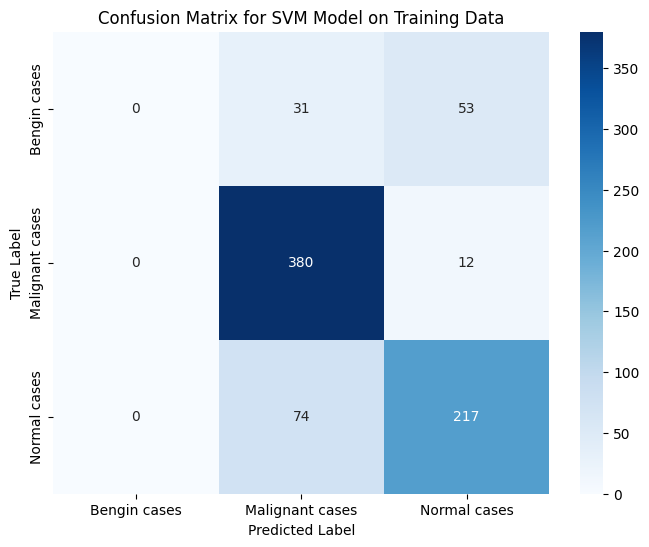

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get class names for labeling the plot
class_names = label_encoder.classes_

# Create a heatmap of the training confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Model on Training Data')
plt.show()

In [72]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

# Load dataset (example dataset)
data = load_digits()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create SVM model
model = svm.SVC(kernel='rbf', C=10, gamma='scale')

# Train model
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Validation Accuracy:", test_acc)

Training Accuracy: 1.0
Validation Accuracy: 0.9805555555555555


**Reasoning**:
To initialize the lists and define the range of 'C' values, I will use a code block to create `training_accuracies`, `validation_accuracies`, and `c_values` as instructed.



In [73]:
import numpy as np

# Initialize empty lists to store training and validation accuracies
training_accuracies = []
validation_accuracies = []

# Define the range of 'C' values from 1 to 29 (inclusive)
c_values = np.arange(1, 30)

print("Accuracy lists initialized and C values defined.")

Accuracy lists initialized and C values defined.


In [76]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_digits()
X = data.data
y = data.target

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("y_train:", y_train.shape)

Shapes:
X_train_scaled: (1437, 64)
y_train: (1437,)


Starting SVM training and evaluation for different C values...
C=0.01: Training Accuracy = 0.1545, Validation Accuracy = 0.1111
C=0.1: Training Accuracy = 0.9582, Validation Accuracy = 0.9472
C=1: Training Accuracy = 0.9972, Validation Accuracy = 0.9806
C=10: Training Accuracy = 1.0000, Validation Accuracy = 0.9806
C=50: Training Accuracy = 1.0000, Validation Accuracy = 0.9806
C=100: Training Accuracy = 1.0000, Validation Accuracy = 0.9806


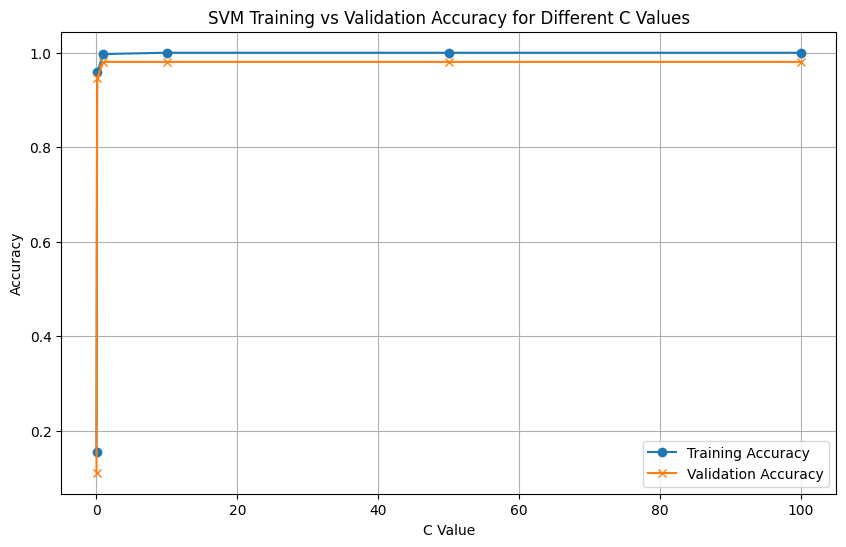

In [77]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

c_values = [0.01, 0.1, 1, 10, 50, 100]

training_accuracies = []
validation_accuracies = []

print("Starting SVM training and evaluation for different C values...")

for c in c_values:

    svm_model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)

    svm_model.fit(X_train_scaled, y_train)

    y_train_pred = svm_model.predict(X_train_scaled)
    y_val_pred = svm_model.predict(X_val_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    training_accuracies.append(train_acc)
    validation_accuracies.append(val_acc)

    print(f"C={c}: Training Accuracy = {train_acc:.4f}, Validation Accuracy = {val_acc:.4f}")

plt.figure(figsize=(10,6))
plt.plot(c_values, training_accuracies, marker='o', label='Training Accuracy')
plt.plot(c_values, validation_accuracies, marker='x', label='Validation Accuracy')

plt.title('SVM Training vs Validation Accuracy for Different C Values')
plt.xlabel('C Value')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()